# Problem Solution Pipeline

In [2]:
import os
import pandas as pd
from pymongo import MongoClient, errors
from dotenv import load_dotenv

# Loading environment variables
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")
if not MONGO_URI:
    raise ValueError("MONGO_URI not found in environment. Check your .env file.")

# Connecting to MongoDB Atlas
try:
    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    db = client["climate_db"]
    col = db["temperature_anomalies"]
    client.admin.command("ping")
    print("Connected to MongoDB Atlas successfully.")
    print(f"Total documents in collection: {col.count_documents({})}")
except errors.ServerSelectionTimeoutError as e:
    print(f"Could not connect to MongoDB: {e}")

Connected to MongoDB Atlas successfully.
Total documents in collection: 23267


In [3]:
# Querying MongoDB and loading into a dataframe
cursor = col.find({}, {"_id": 0, "country": 1, "year": 1, "month": 1,
                        "monthly_anomaly_c": 1, "monthly_anomaly_unc_c": 1,
                        "annual_anomaly_c": 1})

df = pd.DataFrame(list(cursor))
print(f"Raw dataframe shape: {df.shape}")
df.head()

Raw dataframe shape: (23267, 6)


,country,year,month,annual_anomaly_c,monthly_anomaly_c,monthly_anomaly_unc_c
0,united-states,1768,9,NaN,-1.186,2.432
1,united-states,1768,10,NaN,-1.818,2.829
2,united-states,1768,11,-0.663,-1.590,3.599
3,united-states,1768,12,-0.429,-0.978,4.940
4,united-states,1769,1,-0.378,-0.150,5.222


## EDA

In [4]:
# Checking for null values
print("Null counts per column:")
print(df.isnull().sum())
print(f"\nTotal rows with at least one null: {df.isnull().any(axis=1).sum()}")

Null counts per column:
country                     0
year                        0
month                       0
annual_anomaly_c         1872
monthly_anomaly_c        1602
monthly_anomaly_unc_c    1602
dtype: int64

Total rows with at least one null: 1911


In [7]:
# Dropping rows with null values
df_clean = df.dropna()
print(f"Shape after dropping nulls: {df_clean.shape}")

Shape after dropping nulls: (21356, 6)


We drop rows with null values for better analysis performing. We do this instead of imputing the null values so that we do not bias the analysis, as we have sufficient data when dropping all these rows.

In [8]:
# Basic statistics for numerical features
df.describe()

,year,month,annual_anomaly_c,monthly_anomaly_c,monthly_anomaly_unc_c
count,23267.000000,23267.000000,21395.000000,21665.000000,21665.00000
mean,1919.074784,6.503073,-0.027365,-0.028934,0.72646
std,62.972203,3.452024,0.668628,1.249675,0.92533
min,1750.000000,1.000000,-2.566000,-9.599000,0.03900
25%,1875.000000,4.000000,-0.452000,-0.665000,0.21100
50%,1923.000000,7.000000,-0.090000,-0.042000,0.35300
75%,1972.000000,10.000000,0.330000,0.621000,0.90500
max,2020.000000,12.000000,3.756000,7.578000,12.16900


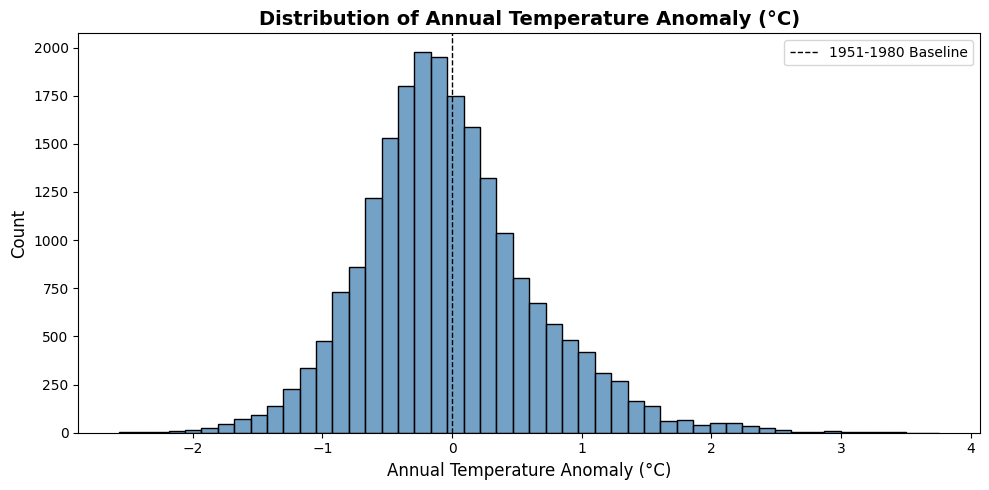

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of target variable
plt.figure(figsize=(10, 5))
sns.histplot(df["annual_anomaly_c"].dropna(), bins=50, color="steelblue", edgecolor="black")
plt.title("Distribution of Annual Temperature Anomaly (°C)", fontsize=14, fontweight="bold")
plt.xlabel("Annual Temperature Anomaly (°C)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.axvline(0, color="black", linestyle="--", linewidth=1, label="1951-1980 Baseline")
plt.legend()
plt.tight_layout()
plt.show()

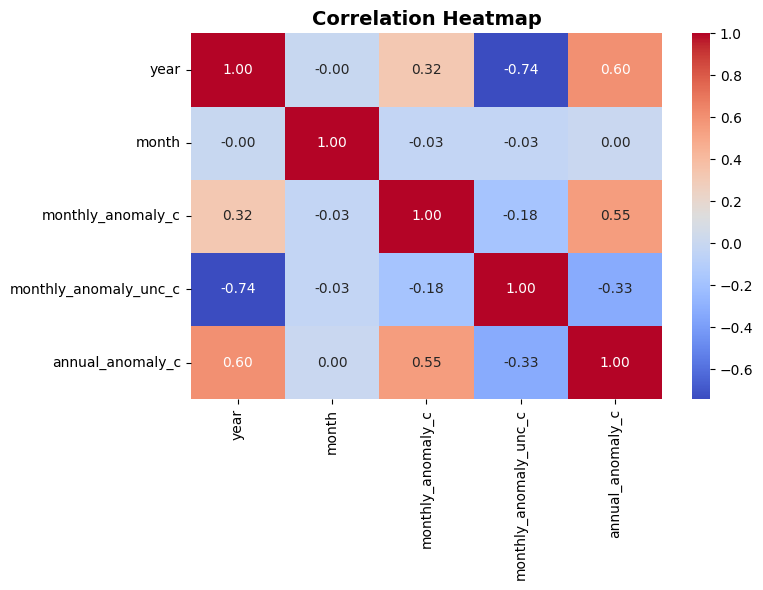

In [10]:
# Correlation heatmap of features and target
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[["year", "month", "monthly_anomaly_c", "monthly_anomaly_unc_c", "annual_anomaly_c"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

We plot the correlation heatmap to identify which variables we expect to best predict our target variable, annual_anomaly _c. This also helps us identify any multicollinearity.

## Data Preprocessing

In [12]:
# One-hot encoding country
df_model = pd.get_dummies(df_clean, columns=["country"], drop_first=True)

# Defining features and target
feature_cols = ["year", "month", "monthly_anomaly_c", "monthly_anomaly_unc_c"] + \
               [col for col in df_model.columns if col.startswith("country_")]

X = df_model[feature_cols]
y = df_model["annual_anomaly_c"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (21356, 13)
Target shape: (21356,)

Feature columns: ['year', 'month', 'monthly_anomaly_c', 'monthly_anomaly_unc_c', 'country_brazil', 'country_canada', 'country_china', 'country_egypt', 'country_germany', 'country_india', 'country_nigeria', 'country_russia', 'country_united-states']


We one hot encode the only categorical variable, which is country, as the model can only understand numeric values.

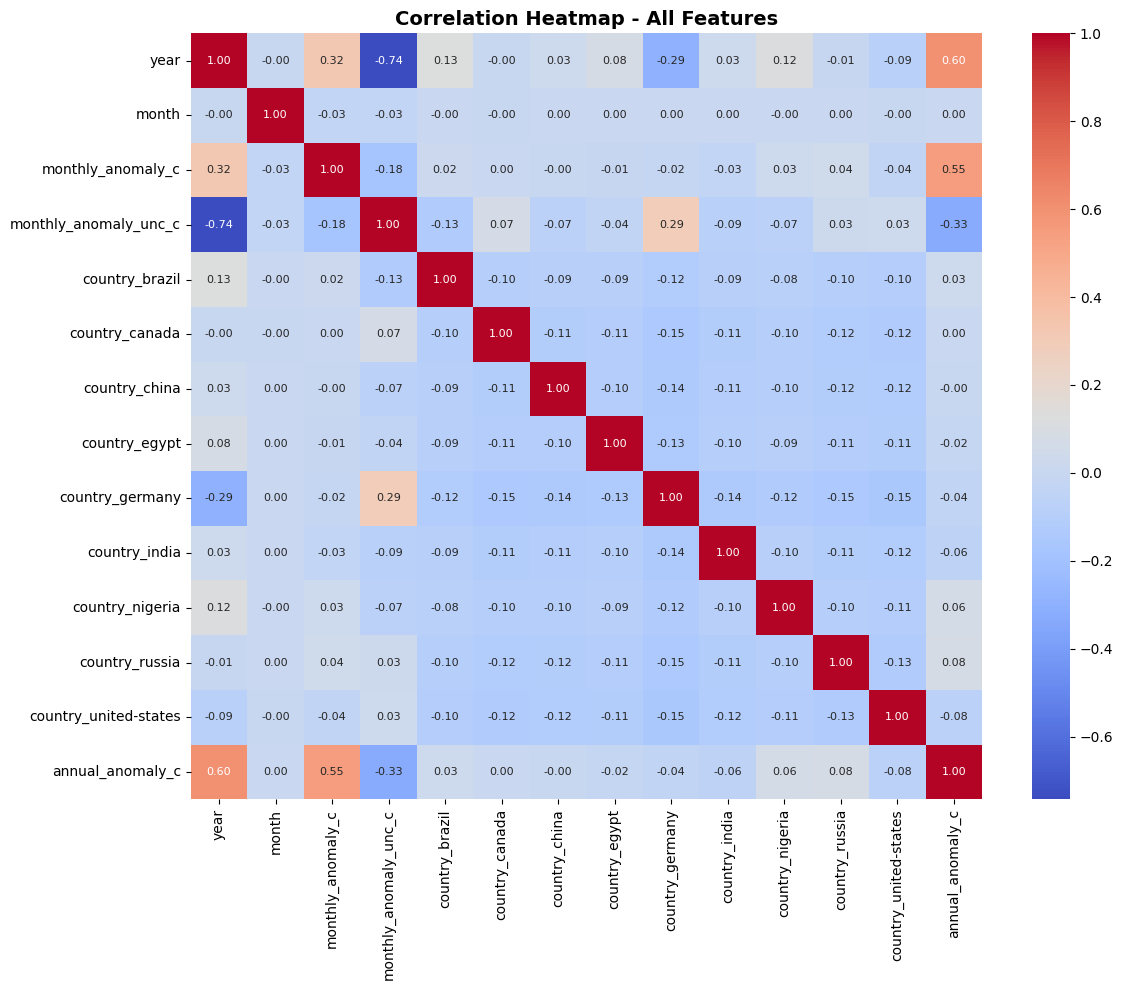

In [13]:
# Updated correlation heatmap with one-hot encoded features
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_model[feature_cols + ["annual_anomaly_c"]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 8}
)
plt.title("Correlation Heatmap - All Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

We plot a new correlation heatmap since the one-hot encoding process led to the creation of new variables representing country

## Modeling

In [34]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building XGBoost pipeline
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))
])

# Hyperparameter grid
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 10],
    "model__learning_rate": [0.01, 0.1, 0.3],
    "model__min_child_weight": [1, 5, 10]
}

# Grid search with 5-fold cross validation
xgb_grid_search = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=3
)

xgb_grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {xgb_grid_search.best_params_}")
print(f"Best cross-validation R²: {xgb_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV 1/5] END model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100;, score=0.496 total time=   0.1s
[CV 2/5] END model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100;, score=0.490 total time=   0.1s
[CV 3/5] END model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100;, score=0.496 total time=   0.1s
[CV 5/5] END model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100;, score=0.511 total time=   0.1s
[CV 2/5] END model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=200;, score=0.580 total time=   0.2s
[CV 4/5] END model__learning_rate=0.01, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100;, score=0.490 total time=   0.1s
[CV 1/5] END model__learning_rate=0.01, model__max_depth=3, model__min_chi

In [37]:
# Evaluating best model on test set
best_xgb = xgb_grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\n=== XGBoost Model Performance ===")
print(f"R²:   {r2_xgb:.4f}")
print(f"MAE:  {mae_xgb:.4f} °C")
print(f"RMSE: {rmse_xgb:.4f} °C")


=== XGBoost Model Performance ===
R²:   0.7375
MAE:  0.2405 °C
RMSE: 0.3398 °C


### Analysis Rationale

The dataset was split 80/20 into training and test sets using a random split with a fixed random state of 42 for reproducibility. The feature set X consists of year, month, monthly_anomaly_c, and monthly_anomaly_unc_c, along with one-hot encoded country columns to represent each country as an independent binary feature without implying a false numeric ordering. The target variable y is annual_anomaly_c, representing the 12-month smoothed temperature anomaly in degrees Celsius relative to the 1951–1980 baseline. XGBoost was selected as the model because it handles non-linear relationships and feature interactions well, which is important for climate data where warming trends vary significantly across countries and time periods. A scikit-learn pipeline was used to chain StandardScaler and XGBoost into a single object to prevent data leakage by ensuring scaling parameters are learned only from the training data. Hyperparameters were tuned via GridSearchCV across 54 combinations with 5-fold cross-validation to find the optimal balance between model complexity and generalization, yielding best parameters of learning_rate = 0.1, max_depth = 10, min_child_weight = 1, and n_estimators = 200.

The final XGBoost model achieved a test R² of approximately 0.74, MAE of 0.24°C, and RMSE of 0.34°C, with a cross-validation R² of 0.72 confirming strong generalization. The remaining 26% of unexplained variance is likely attributable to missing climate drivers not present in this dataset, such as CO₂ concentration.

## Visualization

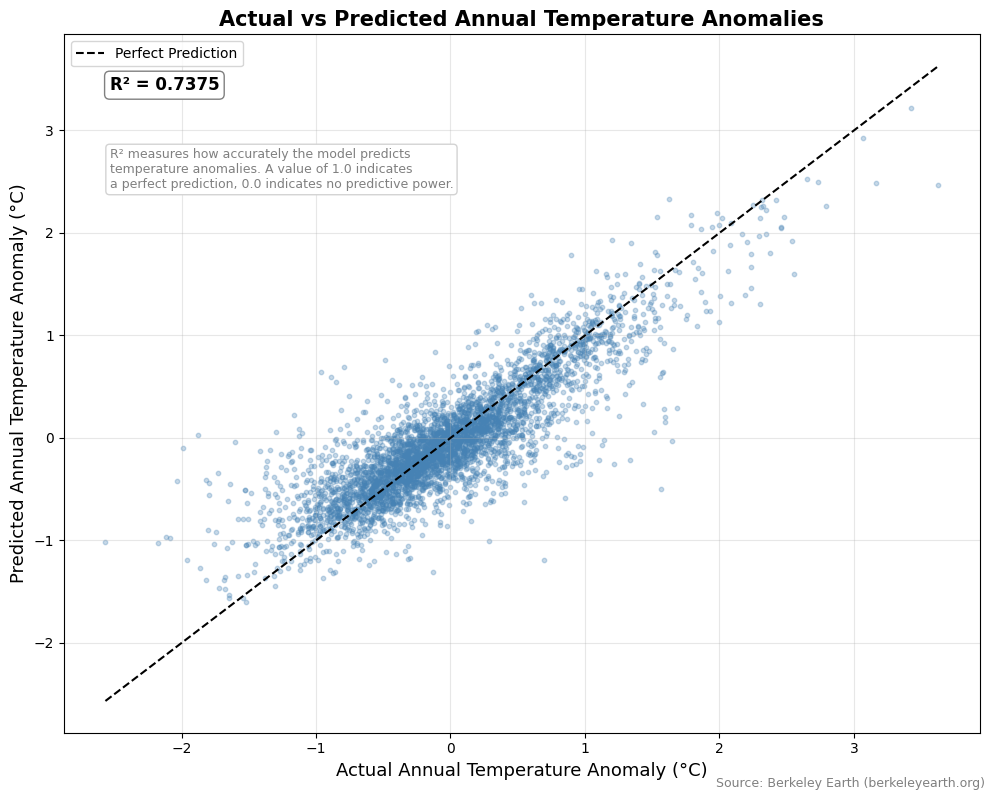

In [45]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(y_test, y_pred_xgb, alpha=0.3, s=10, color="steelblue")

# Perfect prediction line
min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())
ax.plot([min_val, max_val], [min_val, max_val], color="black",
        linewidth=1.5, linestyle="--", label="Perfect Prediction")

# R² annotation
ax.annotate(f"R² = {r2_xgb:.4f}",
            xy=(0.05, 0.92), xycoords="axes fraction",
            fontsize=12, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray"))

# Explanation of R² for a non-technical audience
ax.annotate("R² measures how accurately the model predicts\ntemperature anomalies. A value of 1.0 indicates\na perfect prediction, 0.0 indicates no predictive power.",
            xy=(0.05, 0.78), xycoords="axes fraction",
            fontsize=9, color="gray",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="lightgray"))

ax.set_xlabel("Actual Annual Temperature Anomaly (°C)", fontsize=13)
ax.set_ylabel("Predicted Annual Temperature Anomaly (°C)", fontsize=13)
ax.set_title("Actual vs Predicted Annual Temperature Anomalies",
             fontsize=15, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.text(0.99, 0.01, "Source: Berkeley Earth (berkeleyearth.org)",
         ha="right", fontsize=9, color="gray")
plt.tight_layout()
plt.savefig("../visualizations/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization Rationale

An actual vs predicted scatter plot was chosen because it directly and intuitively communicates how well the model performs to both technical and non-technical audiences. Each point represents one monthly observation, with its actual temperature anomaly on the x-axis and the model's predicted value on the y-axis. Points that fall along the dashed perfect prediction line indicate accurate predictions, while points further away represent larger errors. The tight clustering of points along this line confirms that the model is capturing the underlying warming trends well across all 10 countries. The R² annotation was included with a simple explanation to make the model's accuracy immediately interpretable without requiring statistical knowledge.